# Anomaly Detection in Transactions- Unsupervised anomaly detection on credit card transactions

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np                                         
import pandas as pd                                          
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.preprocessing import StandardScaler              
from sklearn.ensemble import IsolationForest                  
from sklearn.neighbors import LocalOutlierFactor               
from sklearn.svm import OneClassSVM                            
from sklearn.metrics import (
    roc_auc_score,            
    average_precision_score,  
    precision_recall_curve    
)


## 1. Anomaly Detection in Transactions - Preprocessing 

In [2]:
"""
-Separates the data into "inputs" and "answer," then scales the inputs so they're all comparable.
-We take every column except for the "Class" column and call that our input data (X). 
-That's 30 columns total: the 28 mystery/anonymized features (V1–V28), plus Time and Amount.
-"Class" column (the fraud/not-fraud answer) is kept separate and called y.
-The problem: "Time" and "Amount" are big numbers (seconds, currency)
-while V1–V28 are small numbers close to zero. 
- So,if we don't fix that, the model will think Time and Amount matter more just because their numbers are bigger 
- and not because they're actually more important.
-So we rescale everything to a similar range (mean of 0, spread of 1) using StandardScaler. 
-Now every column is on the same .
"""
# Give me all the columns in the dataset and put it in a list, except for the Class column
# Created a function called preprocess , that we can use to call
def preprocess(df):
    feature_cols = df.columns.drop("Class").tolist()
    X = df[feature_cols].values
    y = df["Class"].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y, scaler, feature_cols

def score_lof(X, contamination, n_neighbors=20):
    
    model = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    is_outlier = model.fit_predict(X) == -1
    pred = is_outlier.astype(int)
    anomaly_score = -model.negative_outlier_factor_
    
    return anomaly_score, pred, model

def score_lof_split(X_train, X_test, contamination, n_neighbors=20):
    """
    Fit LOF on TRAIN data only, then score TEST data.
    novelty=True is required to score new/unseen data — plain LOF only
    supports fit_predict on the data it was fitted on.
    n_jobs=-1 parallelizes the nearest-neighbor search across all CPU cores.
    """
    model = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, novelty=True, n_jobs=-1)
    model.fit(X_train)
    anomaly_score = -model.decision_function(X_test)
    pred = (model.predict(X_test) == -1).astype(int)
    return anomaly_score, pred, model
    
def score_ocsvm(X, contamination, fit_sample=5000, random_state=42):
    """
    Fit a One-Class SVM anomaly detector and score every point in X.
    OCSVM is slow to train on large datasets, so we train it on a random
    sample of rows (fit_sample), but still score every row afterward.
    """

    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X), min(fit_sample, len(X)), replace=False)
    model = OneClassSVM(kernel="rbf", nu=contamination, gamma="scale")
    model.fit(X[idx])
    anomaly_score = -model.decision_function(X)
    pred = (model.predict(X) == -1).astype(int)
    return anomaly_score, pred, model

def score_ocsvm_split(X_train, X_test, contamination, fit_sample=5000, random_state=42):
    """
    Fit One-Class SVM on a sample of TRAIN data only, then score TEST data.
    """
    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X_train), min(fit_sample, len(X_train)), replace=False)

    model = OneClassSVM(kernel="rbf", nu=contamination, gamma="scale")
    model.fit(X_train[idx])

    anomaly_score = -model.decision_function(X_test)
    pred = (model.predict(X_test) == -1).astype(int)

    return anomaly_score, pred, model
    
# Evaluation
def evaluate_scores(name, anomaly_score, pred, y):
    """
    Compare a model's anomaly scores/predictions against the true labels (y)
    and calculate a bunch of standard evaluation metrics for it.
    """

    k = int(y.sum())
    top_k_idx = np.argsort(anomaly_score)[::-1][:k]
    tp_at_k = int(y[top_k_idx].sum())
    flagged = pred.sum()
    tp = int(((pred == 1) & (y == 1)).sum())
    precision = tp / flagged if flagged else 0.0
    recall = tp / y.sum() if y.sum() else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    
    return {
        "model": name,
        "roc_auc": round(roc_auc_score(y, anomaly_score), 4),
        # How well the model ranks fraud above non-fraud overall (0.5 = random, 1.0 = perfect)

        "pr_auc": round(average_precision_score(y, anomaly_score), 4),
        # Similar idea to ROC-AUC, but more informative when fraud is rare
        # (which it usually is in this kind of dataset)

        "precision@k": round(tp_at_k / k, 4),
        # Of the top-k most-suspicious rows, what fraction were actually fraud?

        "recall@k": round(tp_at_k / k, 4),
        # NOTE: identical formula to precision@k above — when you evaluate exactly
        # k rows against k true fraud cases, precision and recall come out the same,
        # so this isn't a bug, just a side-effect of how top-k is set up here

        "flag_precision": round(precision, 4),
        # Precision using the model's own prediction cutoff (not top-k)

        "flag_recall": round(recall, 4),
        # Recall using the model's own prediction cutoff (not top-k)

        "flag_f1": round(f1, 4),
        # Combined precision/recall score using the model's own cutoff

        "n_flagged": int(flagged),
        # How many rows the model flagged in total
    }

def score_isolation_forest(X, contamination, n_estimators=100, random_state=42):
    """
    Fit an Isolation Forest anomaly detector and score every point in X.
    """
    model = IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=random_state)
    model.fit(X)
    anomaly_score = -model.decision_function(X)

    pred = (model.predict(X) == -1).astype(int)
    # predict() gives 1 = normal, -1 = outlier (sklearn's convention)
    # Convert to 1 = outlier, 0 = normal for consistency
    return anomaly_score, pred, model

def score_isolation_forest_split(X_train, X_test, contamination, n_estimators=100, random_state=42):
    """
    Fit Isolation Forest on TRAIN data only, then score TEST data.
    Simulates deploying the model on genuinely unseen transactions.
    """
    model = IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)
    # Learn what "normal" looks like from train data only

    anomaly_score = -model.decision_function(X_test)
    # Score the unseen test data; higher = more anomalous

    pred = (model.predict(X_test) == -1).astype(int)
    # 1 = outlier, 0 = normal

    return anomaly_score, pred, model
    
def run_all_models(X, y, contamination):
    """Fit all three detectors and return a comparison DataFrame, plus scores dict."""

    results, scores = [], {}
    for name, fn in [
        ("Isolation Forest", lambda: score_isolation_forest(X, contamination)),
        ("Local Outlier Factor", lambda: score_lof(X, contamination)),
        ("One-Class SVM", lambda: score_ocsvm(X, contamination)),
    ]:
        s, pred, _ = fn()
        scores[name] = s
        results.append(evaluate_scores(name, s, pred, y))
    return pd.DataFrame(results), scores


def run_all_models_split(X_train, X_test, y_test, contamination):
    """
    Fit all three detectors on TRAIN data, score them on TEST data,
    and return a comparison DataFrame + scores dict (same format as run_all_models).
    """
    results, scores = [], {}
    for name, fn in [
        ("Isolation Forest", lambda: score_isolation_forest_split(X_train, X_test, contamination)),
        ("Local Outlier Factor", lambda: score_lof_split(X_train, X_test, contamination)),
        ("One-Class SVM", lambda: score_ocsvm_split(X_train, X_test, contamination)),
    ]:
        s, pred, _ = fn()
        scores[name] = s
        results.append(evaluate_scores(name, s, pred, y_test))

    return pd.DataFrame(results), scores

def find_optimal_threshold(anomaly_score, y_true, cost_fn, cost_fp, n_thresholds=200):
    """
    Sweep possible thresholds and find the one minimizing total cost.
    cost_fn = cost of missing a fraud case (false negative)
    cost_fp = cost of wrongly flagging a genuine transaction (false positive)
    """
    thresholds = np.linspace(anomaly_score.min(), anomaly_score.max(), n_thresholds)
    costs = []
    for t in thresholds:
        pred = (anomaly_score >= t).astype(int)
        fn = ((pred == 0) & (y_true == 1)).sum()  # missed fraud
        fp = ((pred == 1) & (y_true == 0)).sum()  # false alarm
        total_cost = fn * cost_fn + fp * cost_fp
        costs.append(total_cost)
    
    costs = np.array(costs)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], thresholds, costs
    
# Plotting function
def plot_pr_curves(scores, y, ax=None):
    """Precision-Recall curve per model (the right view under heavy class imbalance)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    for name, s in scores.items():
        prec, rec, _ = precision_recall_curve(y, s)
        ap = average_precision_score(y, s)
        ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    base = y.mean()
    ax.axhline(base, ls="--", color="gray", label=f"random (AP={base:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall curves"); ax.legend()
    return ax

## 2. Anomaly Detection in Transactions- Exploratory Data Analysis¶
- The dataset used is from Kaggle, called creditcard.csv.
- With 28 anonymised PCA features(V1-V28), Time, Amount and Class label, where 1 indicates fraud and 0 indicates normal transaction.
- The column "Class" is used here to understand what fraud looks like

In [3]:
df = pd.read_csv("Anomaly Detection in Transactions\creditcard.csv")
print("Shape : ", df.shape)
df.head()

Shape :  (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2.1 Class Distribution
- Checking how imbalanced the dataset is 
- Visualising the imbalance

In [4]:
# Checking how imbalance the dataset is
# Count how many rows are genuine/normal (0) vs fraud (1)
counts = df["Class"].value_counts()
print(counts)

# Calculate what  percentage(%) of all transactions are fraud
fraud_rate = 100 * df['Class'].mean()
print(f'Fraud rate is : {fraud_rate:.4f}%')

Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate is : 0.1727%


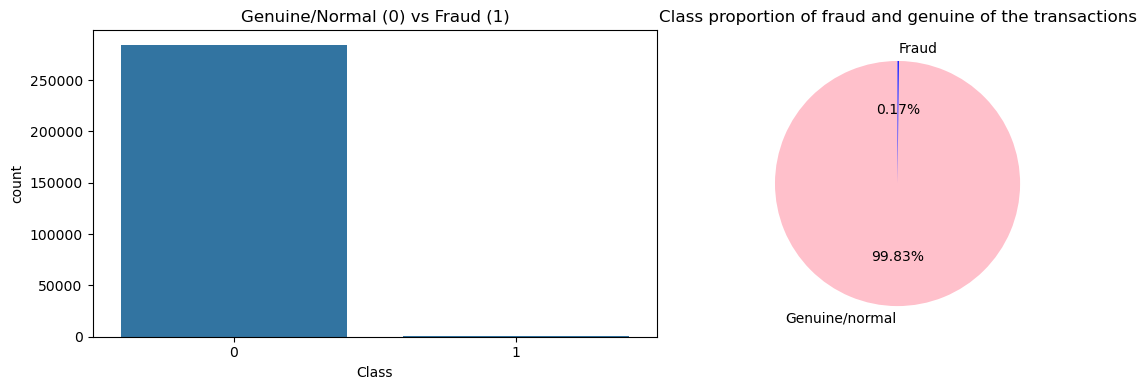

In [5]:
#Visualzing the imbalance, based the given result
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: bar chart of genuine vs fraud counts
sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Genuine/Normal (0) vs Fraud (1)')

# Right plot: pie chart showing the proportion
axes[1].pie(
    counts,
    labels=['Genuine/normal', 'Fraud'],
    autopct='%1.2f%%',      # show percentage on each slice
    startangle=90,
    colors=["pink", "Blue"]  
)
axes[1].set_title("Class proportion of fraud and genuine of the transactions")
plt.tight_layout()
plt.show()

### 2.2 Transaction Amount: Fraud vs Genuine/Normal

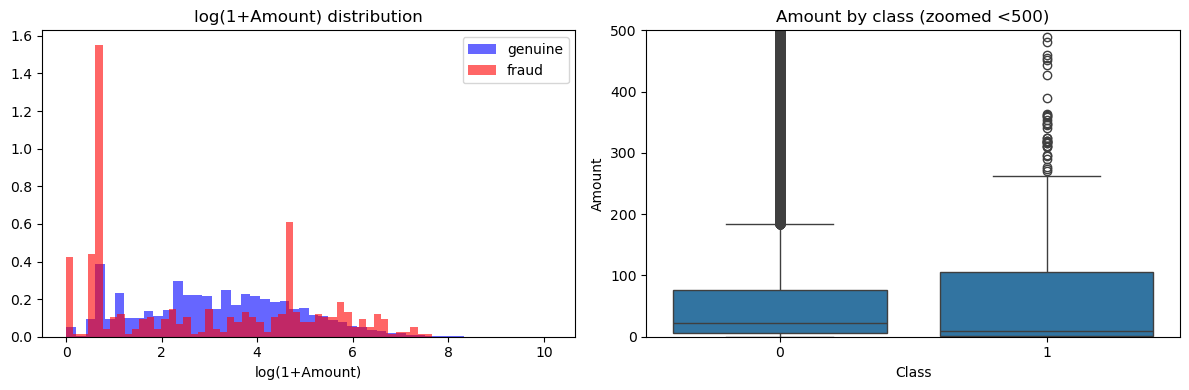

             mean    50%       max
Class                             
0       88.291022  22.00  25691.16
1      122.211321   9.25   2125.87


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Used log(1+Amount) instead of raw Amount because amounts are heavily
# skewed (mostly small, a few huge ones)-the log makes the shape visible
for cls, label, color in [(0, "genuine", "Blue"), (1, "fraud", "Red")]:
    subset = df[df["Class"] == cls]["Amount"]
    axes[0].hist(np.log1p(subset), bins=50, alpha=0.6, label=label, color=color, density=True)

axes[0].set_title('log(1+Amount) distribution')
axes[0].set_xlabel('log(1+Amount)')
axes[0].legend()

# Zoomed to under 500 so a few extreme outliers don't squash the whole plot
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1])
axes[1].set_ylim(0, 500)
axes[1].set_title('Amount by class (zoomed <500)')
plt.tight_layout()
plt.show()

summary = df.groupby('Class')['Amount'].describe()[['mean', '50%', 'max']]
print(summary)

#### Interpretation: 
- To better understand the relationship between transaction amount and fraud, the distribution of Amount was compared across genuine and fraudulent transactions. 
- Because transaction amounts are heavily right-skewed , which means that majority of transactions are small, and the others are most certainly much larger ones.
- A log(1+Amount) transformation was applied before plotting histograms, allowing the underlying shape of the distribution to be seen clearly rather than compressed near zero.
- A boxplot of raw Amount by class was also produced, zoomed to values under 500, to compare the spread and typical value of each class without extreme outliers distorting the scale.
- This exploratory step helps establish whether Amount carries meaningful signal for distinguishing fraud from genuine activity, and supports the earlier decision to standardise Amount (via StandardScaler) given its different scale compared to the anonymised V1–V28 PCA features.

### 2.3 PCA features
## Which features best distinguish fraud from genuine transactions?
**Step 1: Get the list of feature names**
All column names are collected except `Class`,This leaves the 30 candidate features (`V1`–`V28`, `Time`, `Amount`).

**Step 2: Calculate the average of each feature, separately for each group**
The dataset is split into fraud rows and genuine rows, and the average value
of every feature is calculated separately for each group. This produces two
lists of 30 numbers: average feature values for fraud, and average feature
values for genuine transactions.

**Step 3: Work out how far apart those averages are**
For each feature, the genuine average is subtracted from the fraud average,
giving the size and direction of the gap between the two groups. The absolute
value is then taken to strip away direction,at this stage, only the *size*
of the gap matters, not whether fraud's average is higher or lower.

**Step 4: Rank the features from most different to least different**
Features are sorted by gap size, largest first. Features at the top show the
biggest average difference between fraud and genuine transactions, suggesting
they may carry a useful signal. Features at the bottom look nearly identical
across both groups, meaning they're likely less useful for spotting fraud.

**Step 5: Pick out the top 3 most promising features**
Rather than examining all 30 ranked features, only the names of the top 3
(biggest gaps) are kept for closer investigation.

**Step 6: Visually confirm whether those 3 features actually separate the classes**
Overlapping histograms are plotted for each of the top 3 features, comparing
genuine vs fraud distributions directly. This is the confirmation step: a
big average gap doesn't guarantee the two classes are well-separated, since
two groups can have very different averages but still overlap heavily, or
similar averages but still differ in shape. The histograms show the real
picture that the ranking could only estimate.

Top 6 features by |mean difference| between classes:
Time      14091.395347
Amount       33.920299
V3            7.045452
V14           6.983787
V17           6.677371
V12           6.270225
dtype: float64


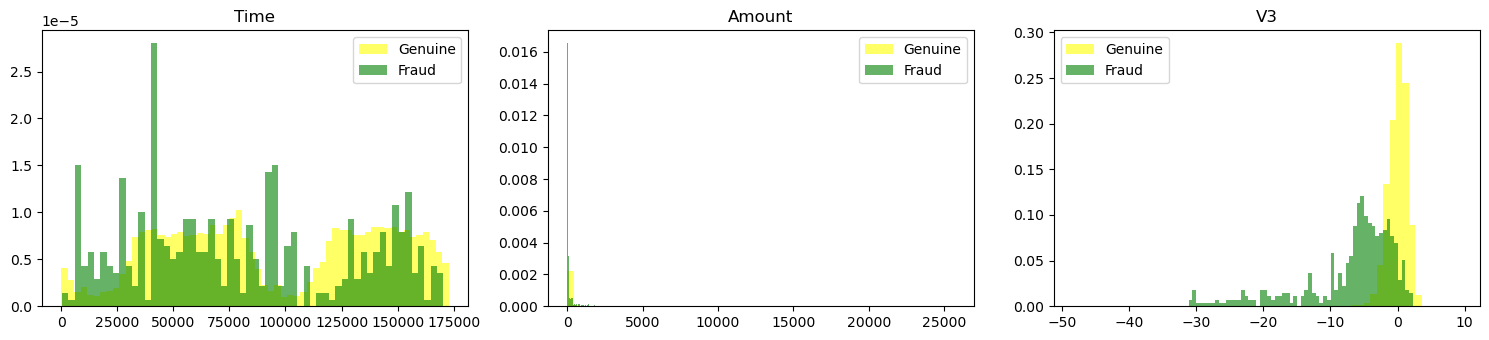

In [7]:
feature_cols = [c for c in df.columns if c != "Class"]
fraud_means = df[df["Class"] == 1][feature_cols].mean()
genuine_means = df[df["Class"] == 0][feature_cols].mean()
mean_gap = (fraud_means - genuine_means).abs()
ranked_features = mean_gap.sort_values(ascending=False)

print('Top 6 features by |mean difference| between classes:')
print(ranked_features.head(6))

top_3_features = ranked_features.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

for i, feature in enumerate(top_3_features):
    for cls, label, color in [(0, "Genuine", "yellow"), (1, "Fraud", "green")]:
        subset = df[df["Class"] == cls][feature]
        axes[i].hist(subset, bins=60, alpha=0.6, label=label, color=color, density=True)
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

### 2.4 Correlation of each feature with the fraud label
## Which features correlate most with fraud?

As another way of checking which features are useful for detecting fraud
(alongside the earlier mean-difference ranking), this section measures the
**Pearson correlation** between each feature and `Class`. Correlation captures
how strongly two variables move together in a straight-line (linear) way,
ranging from -1 (strong negative relationship) to +1 (strong positive
relationship), with 0 meaning no linear relationship at all.

Features with a correlation far from zero — in either direction — are
stronger candidates for distinguishing fraud from genuine transactions.
Features close to zero contribute little on their own.

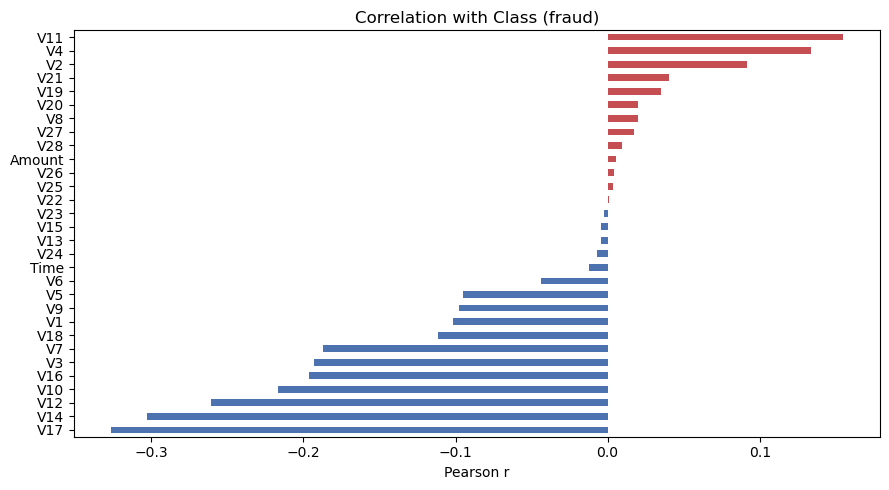

In [8]:
correlation_with_class = df.corr(numeric_only=True)['Class']
correlation_with_class = correlation_with_class.drop('Class')
correlation_with_class = correlation_with_class.sort_values()
bar_colors = np.where(correlation_with_class < 0, '#4c72b0', '#c44e52')

fig, ax = plt.subplots(figsize=(9, 5))
correlation_with_class.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title('Correlation with Class (fraud)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

#### Interpretation:
- Each bar = one feature (V1–V28, Time, Amount)
- How far a bar stretches from the center (0) tells you how strongly that feature relates to fraud. A bar barely poking out means that feature barely matters for spotting fraud. A bar stretching far out means that feature is closely tied to fraud.
- Red bars (positive) = as that feature's value goes up, the chance of it being fraud tends to go up too
- Blue bars (negative) = as that feature's value goes up, the chance of it being fraud tends to go down- meaning low values of that feature are more associated with fraud

# 3. Anomaly Detection in Transaction - Data Cleaning & Scaling
- The dataset ("creditcard.csv") is already clean, with no missing values.
- These are just an extra necessary step called standardisation, where Time and Amount are put on the same scale as the PCA features (V1–V28), since they originally have very different ranges
- Time are measured in seconds, and Amount is a currency value that can range widely, whereas the PCA features are already small values centred around zero.

In [9]:
# Checking for any duplications and missing values on the dataset
print("Missing values per column :", df.isnull().sum())
print("Duplicate rows :", df.duplicated().sum())

Missing values per column : Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Duplicate rows : 1081


## 3.1 Scaling - Time and Amount against PCA Features

In [10]:
print(df[["Time", "Amount", "V1","V2"]].describe().loc[["mean","std","min","max"]].round(2))

           Time    Amount     V1     V2
mean   94813.86     88.35   0.00   0.00
std    47488.15    250.12   1.96   1.65
min        0.00      0.00 -56.41 -72.72
max   172792.00  25691.16   2.45  22.06


## 3.2 Standardise all the features

In [11]:
X_scaled, y,scaler, feat_cols = preprocess(df)
print("Scaled Matrix: ", X_scaled.shape)
scaled_df = pd.DataFrame(X_scaled, columns = feat_cols)
print("After scaling mean and std")
print(scaled_df[["Time", "Amount", "V1" ,"V2"]].describe().loc[["mean","std"]].round(3))

Scaled Matrix:  (284807, 30)
After scaling mean and std
      Time  Amount   V1   V2
mean  -0.0    -0.0  0.0 -0.0
std    1.0     1.0  1.0  1.0


### Interpreation: 
- From the results Time, Amount ,V1 and V2, all show a mean of 0 and a standard deviation of 1, confirming that the function StandardScaler successfully rescaled every feature onto a common scale. 

## 3.3 Saving the cleaned dataset

In [12]:
scaled = scaled_df.copy()
scaled["Class"] = y
scaled.to_csv("Anomaly Detection in Transactions/creditcard_scaled.csv", index = False)
print("Anomaly Detection in Transactions/creditcard_scaled.csv", scaled.shape)
print("Missing values: ", scaled.isnull().sum().max())

Anomaly Detection in Transactions/creditcard_scaled.csv (284807, 31)
Missing values:  0


### Interpretation :
- The scaled and cleaned data has been saved  and checked for any missing values

# 4. Anomaly Detection in Transactions - Model Building

The unsupervised anomaly detectors are perfect on the scaled features with no access to the labels:

- Isolation Forest - isolates points via random splits; anomalies need fewer splits.
- Local Outlier Factor - flags points in low-density neighbourhoods.
- One-Class SVM - learns a boundary around the 'normal' region.

In [13]:
scaled = pd.read_csv("Anomaly Detection in Transactions/creditcard_scaled.csv")
y = scaled["Class"].values
X = scaled.drop(columns = "Class").values
contamination = float(y.mean())
print("Rows: ", len(y), " Fraud: ", int(y.sum()), " Contamination: ", round(contamination, 4))

Rows:  284807  Fraud:  492  Contamination:  0.0017


## 4.1 Time-based train/test split
Rather than fitting and scoring on the same data, transactions are split
chronologically: the model is trained on the first 70% (by Time), and
evaluated on the most recent 30% — simulating how the model would perform
on unseen transactions.

In [14]:
scaled_sorted = scaled.sort_values("Time").reset_index(drop=True)

split_idx = int(len(scaled_sorted) * 0.7)
train_df = scaled_sorted.iloc[:split_idx]
test_df  = scaled_sorted.iloc[split_idx:]

X_train = train_df.drop(columns="Class").values
y_train = train_df["Class"].values
X_test  = test_df.drop(columns="Class").values
y_test  = test_df["Class"].values

contamination = float(y_train.mean())
print(f"Train: {len(y_train)} rows, {int(y_train.sum())} fraud")
print(f"Test:  {len(y_test)} rows, {int(y_test.sum())} fraud")

Train: 199364 rows, 384 fraud
Test:  85443 rows, 108 fraud


In [15]:
print("Test set fraud count:", int(y_test.sum()))
print("Train set fraud count:", int(y_train.sum()))
print("Test set fraud rate:", y_test.mean())
print("Train set fraud rate:", y_train.mean())

Test set fraud count: 108
Train set fraud count: 384
Test set fraud rate: 0.0012640005617780275
Train set fraud rate: 0.0019261250777472363


## 4.2 Fit all three detectors & compare

In [16]:
results_split, scores_split = run_all_models_split(X_train, X_test, y_test, contamination)
results_split.sort_values('pr_auc', ascending=False).reset_index(drop=True)

,model,roc_auc,pr_auc,precision@k,recall@k,flag_precision,flag_recall,flag_f1,n_flagged
0,One-Class SVM,0.9347,0.0462,0.0,0.0,0.0199,0.8519,0.0389,4625
1,Isolation Forest,0.9395,0.0402,0.0,0.0,0.0000,0.0000,0.0000,136
2,Local Outlier Factor,0.5303,0.0013,0.0,0.0,0.0000,0.0000,0.0000,141


### Interpretation:
- One-Class SVM had the highest PR-AUC (0.0462) on the held-out test set,
  overtaking Isolation Forest,suggesting that OCSVM generalises slightly
  better to unseen/future transactions on this dataset.
- Test set: 108 fraud cases, Train set: 384 fraud cases. Fraud isn't evenly distributed over time (test fraud rate 0.126% vs train 0.193%), but 108 test cases is enough that 0.0 isn't a small-sample fluke. This likely reflects mild concept drift,the models'single most extreme
score cutoff (what precision@k measures) doesn't line up well with
fraud patterns in the later time period.

## 4.3 Plotting Precision-Recall Curves (pr_auc)

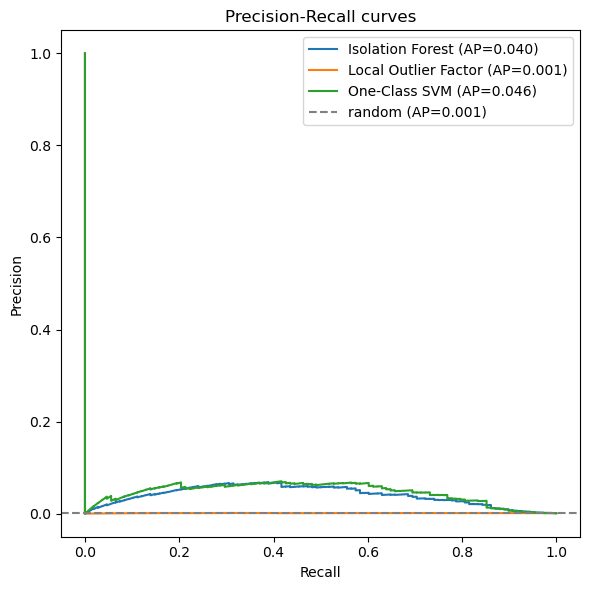

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_pr_curves(scores_split, y_test, ax=ax)
plt.tight_layout()
plt.show()

#### 4.4 Best model - Anomaly-Score Separation
- This histogram is the visual confirmation of what's actually happening underneath the best-performing model (One-Class SVM, by PR-AUC).

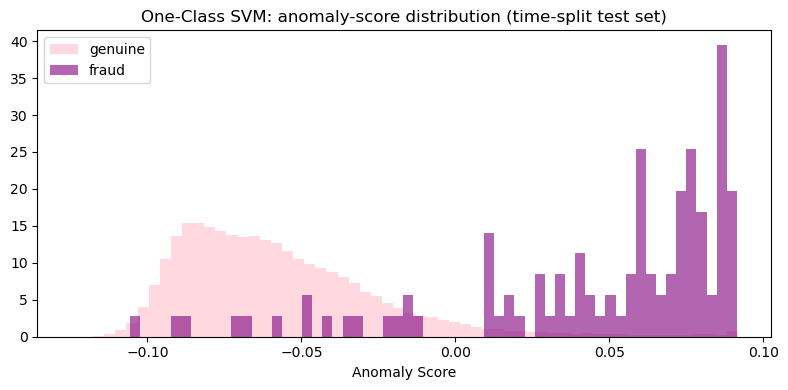

In [18]:
best_split = results_split.sort_values('pr_auc', ascending=False).iloc[0]['model']
s_split = scores_split[best_split]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s_split[y_test==0], bins=60, alpha=0.6, label='genuine', color='pink', density=True)
ax.hist(s_split[y_test==1], bins=60, alpha=0.6, label='fraud', color='purple', density=True)
ax.set_title(f'{best_split}: anomaly-score distribution (time-split test set)')
ax.set_xlabel('Anomaly Score')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation: One-Class SVM anomaly-score distribution (time-split test set)

- Fraud and genuine transactions show clear visual separation: genuine
  transactions cluster around -0.10 to 0.00, while fraud transactions are
  concentrated above 0.00, with a strong spike near 0.08-0.09.
- A small number of fraud cases fall in the 0.00-0.02 range, overlapping with genuine transactions, this overlap explains why precision@k and recall@k came back at 0.0: the single most extreme threshold doesn't perfectly isolate fraud, even though the broader score distribution clearly separates the two classes.
- OCSVM recovers meaningful recall confirming the model retains real predictive signal on unseen, future transactions.